In [1]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

✗ Running locally (not Colab)
Python version: 3.12.9 (main, Mar 17 2025, 21:01:58) [Clang 20.1.0 ]
Executable: /home/user/deep-learning-from-scratch-2/.venv/bin/python
Working Directory: /home/user/deep-learning-from-scratch-2/notebooks


In [ ]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b master https://github.com/AcademiXBase/deep-learning-from-scratch-2.git
#%cd deep-learning-from-scratch-2

In [2]:
# coding: utf-8
import sys
sys.path.append('..')

import numpy as np

from common.layers import MatMul, SoftmaxWithLoss
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot

In [3]:
# ch04/negative_sampling_layer.py

# coding: utf-8
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding, SigmoidWithLoss
import collections


class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh


class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # GPU(cupy）で計算するときは、速度を優先
            # 負例にターゲットが含まれるケースがある
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample


class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 正例のフォワード
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 負例のフォワード
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh


In [4]:
# ch04/cbow.py

# coding: utf-8
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding
# from ch04.negative_sampling_layer import NegativeSamplingLoss


class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # レイヤの生成
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)  # Embeddingレイヤを使用
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # すべての重みと勾配をリストにまとめる
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None


In [5]:
# ch04/skip_gram.py

# coding: utf-8
import sys
sys.path.append('..')  # 親ディレクトリのファイルをインポートするための設定
from common.layers import *
# from ch04.negative_sampling_layer import NegativeSamplingLoss


class SkipGram:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size
        rn = np.random.randn

        # 重みの初期化
        W_in = 0.01 * rn(V, H).astype('f')
        W_out = 0.01 * rn(V, H).astype('f')

        # レイヤの生成
        self.in_layer = Embedding(W_in)
        self.loss_layers = []
        for i in range(2 * window_size):
            layer = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)
            self.loss_layers.append(layer)

        # すべての重みと勾配をリストにまとめる
        layers = [self.in_layer] + self.loss_layers
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)

        loss = 0
        for i, layer in enumerate(self.loss_layers):
            loss += layer.forward(h, contexts[:, i])
        return loss

    def backward(self, dout=1):
        dh = 0
        for i, layer in enumerate(self.loss_layers):
            dh += layer.backward(dout)
        self.in_layer.backward(dh)
        return None


In [ ]:
"""
CPUで学習
"""

# ch04/train.py

# coding: utf-8
import sys
sys.path.append('..')
from common import config
# GPUで実行する場合は、下記のコメントアウトを消去（要cupy）
# ===============================================
# config.GPU = True
# ===============================================
from common.np import *
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
# from cbow import CBOW
# from skip_gram import SkipGram
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb


# ハイパーパラメータの設定
window_size = 5
hidden_size = 100
batch_size = 4096
max_epoch = 10

# データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# モデルなどの生成
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 学習開始
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 後ほど利用できるように、必要なデータを保存
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = '../ch04/cbow_params.pkl'  # or 'skipgram_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)


------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------

| epoch 1 |  iter 1 / 226 | time 0[s] | loss 4.16
| epoch 1 |  iter 21 / 226 | time 0[s] | loss 4.15
| epoch 1 |  iter 41 / 226 | time 0[s] | loss 4.08
| epoch 1 |  iter 61 / 226 | time 0[s] | loss 3.84
| epoch 1 |  iter 81 / 226 | time 0[s] | loss 3.47
| epoch 1 |  iter 101 / 226 | time 0[s] | loss 3.11
| epoch 1 |  iter 121 / 226 | time 1[s] | loss 2.85
| epoch 1 |  iter 141 / 226 | time 1[s] | loss 2.71
| epoch 1 |  iter 161 / 226 | time 1[s] | loss 2.64
| epoch 1 |  iter 181 / 226 | time 1[s] | loss 2.60
| epoch 1 |  iter 201 / 226 | time 1[s] | loss 2.58
| epoch 1 |  iter 221 / 226 | time 1[s] | loss 2.57
| epoch 2 |  iter 1 / 226 | time 1[s] | loss 2.56
| epoch 2 |  iter 21 / 226 | time 1[s] | loss 2.55
| epoch 2 |  iter 41 / 226 | time 1[s] | loss 2.55
| epoch 2 |  iter 61 / 226 | time 2[s] | loss 2.54
| epoch 2 |  iter

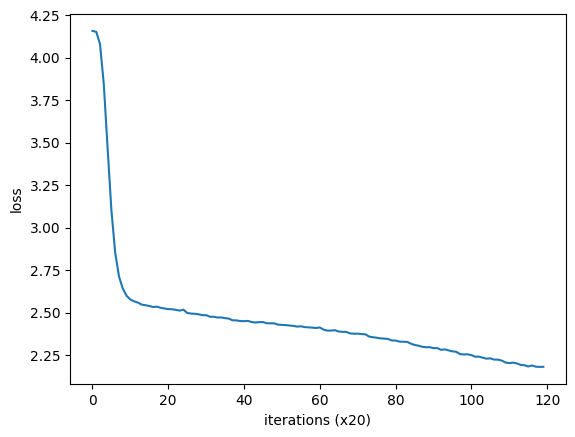

In [7]:
"""
GPUで学習
"""

# coding: utf-8
import sys
sys.path.append('..')

from common import config
import importlib

# GPUで実行
config.GPU = True

import common.np
import common.layers
import ch04.negative_sampling_layer
import ch04.cbow
importlib.reload(common.np)
importlib.reload(common.layers)
importlib.reload(ch04.negative_sampling_layer)
importlib.reload(ch04.cbow)

from common.np import *
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb
from ch04.cbow import CBOW

# from skip_gram import SkipGram


# ハイパーパラメータの設定
window_size = 5
hidden_size = 100
batch_size = 4096
max_epoch = 10

# データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)

if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# モデルなどの生成
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)

optimizer = Adam()
trainer = Trainer(model, optimizer)

# 学習開始
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 後ほど利用できるように、必要なデータを保存
word_vecs = model.word_vecs

# 保存時はNumPy配列に戻す
word_vecs = to_cpu(word_vecs)

params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word

pkl_file = '../ch04/cbow_params.pkl'  # or 'skipgram_params.pkl'

with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

In [8]:
# ch04/eval.py

# coding: utf-8
import sys
sys.path.append('..')
from common.util import most_similar, analogy
import pickle


pkl_file = '../ch04/cbow_params.pkl'
# pkl_file = 'skipgram_params.pkl'

with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

# most similar task
querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)

# analogy task
print('-'*50)
analogy('king', 'man', 'queen',  word_to_id, id_to_word, word_vecs)
analogy('take', 'took', 'go',  word_to_id, id_to_word, word_vecs)
analogy('car', 'cars', 'child',  word_to_id, id_to_word, word_vecs)
analogy('good', 'better', 'bad',  word_to_id, id_to_word, word_vecs)



[query] you
 we: 0.98291015625
 i: 0.9716796875
 're: 0.96630859375
 'm: 0.96484375
 maybe: 0.96484375

[query] year
 month: 0.94970703125
 earlier: 0.91015625
 week: 0.87548828125
 second: 0.8447265625
 period: 0.8427734375

[query] car
 vehicle: 0.94189453125
 tree: 0.94140625
 specially: 0.939453125
 supercomputer: 0.9375
 parking: 0.92919921875

[query] toyota
 shell: 0.94873046875
 k: 0.94775390625
 alberta: 0.9462890625
 mci: 0.9443359375
 tandem: 0.94091796875
--------------------------------------------------

[analogy] king:man = queen:?
 know: 5.421875
 think: 4.50390625
 lot: 4.48046875
 thing: 4.4140625
 you: 4.34375

[analogy] take:took = go:?
 composite: 4.1953125
 know: 3.9765625
 yield: 3.888671875
 daffynition: 3.826171875
 a.m: 3.64453125

[analogy] car:cars = child:?
 daffynition: 4.36328125
 a.m: 4.23046875
 yield: 4.12890625
 priced: 3.8046875
 yen: 3.61328125

[analogy] good:better = bad:?
 know: 4.52734375
 do: 4.38671875
 want: 4.171875
 think: 4.01953125
 goin